In [1]:
%cd ..
from pathlib import Path
import json
from itertools import zip_longest
from py_markdown_table.markdown_table import markdown_table
from numpy import load
from torch import from_numpy
from deepinv.utils import plot

c:\Users\s2558406\Documents\Repos\deepinv-selfsup-fastmri\venv\lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


c:\Users\s2558406\Documents\Repos


In [2]:
ids = {
    "sup": "5aijn6ex",
}

Load results

In [3]:
results = {}
for title, id in ids.items():
    with open(f"M:/models/deepinv-selfsup-fastmri/paper/{id}/results.json", "r") as f:
        results[title] = json.load(f)
    results[title]["sample"] = load(f"M:/models/deepinv-selfsup-fastmri/paper/{id}/samples.npz")

In [4]:
def repr(m, dp=8, p='+'):
    return rf"{str(round(m, dp)).lstrip('0')}" if (m is not None and m != "") else ""
table = [
    {
        "name": k,
        "PSNR": repr(run["PSNR"]),
        "PSNR_nl": repr(run["PSNR no learning"]),
        #"SSIM": repr(run["SSIM"]),
        #"SSIM_nl": repr(run["SSIM no learning"]),
    } for k, run in results.items()
]
print(markdown_table(table).set_params(row_sep="markdown").get_markdown())

```|name|    PSNR   |  PSNR_nl |
|----|-----------|----------|
| sup|21.47550044|25.3967215|```


In [5]:
for m in table:
    print(rf'{m["name"]} & {m["PSNR"]} & {m["PSNR_nl"]} \\')

sup & 21.47550044 & 25.3967215 \\


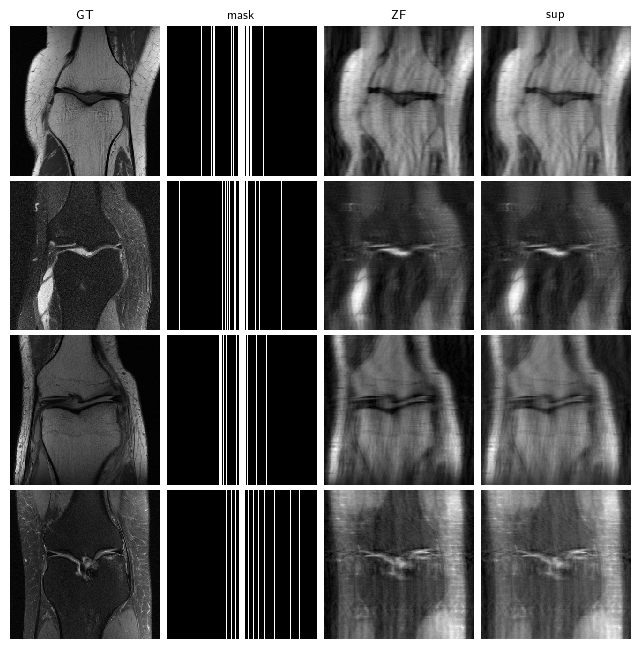

In [6]:
x = from_numpy(results["sup"]["sample"]["x"])
x_init = from_numpy(results["sup"]["sample"]["x_init"])
y = from_numpy(results["sup"]["sample"]["y"])

plot({
    "GT": x, 
    "mask": y != 0, 
    "ZF": x_init
} | {
    k: from_numpy(results[k]["sample"]["x_hat"]) for k in results
})